## Grad-CAM-based model interpretation

This notebook creates segmentation Grad-CAM heatmaps for FMV mapping.

The notebook is: it loads the required model and one raw GeoTIFF, applies the same ResNet preprocessing as training, checks target-layer names, and exports clean nfigures without retraining

#### Author's detail:

Satya Prakash, Michael Wachendorf, Sunil Nautiyal, Jayan Wijesingha

Section of Grassland Science and Renewable Plant Resources, Faculty of Organic Agricultural Sciences,

University of Kassel, Steinstraße 19, D-37213 Witzenhausen Germany

For any query: satyaprakash724.sp@gmail.com; satya.prakash@uni-kassel.de

In [1]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow import keras
import segmentation_models as sm
import albumentations as A
import keras.backend as K

2026-08-14 15:44:25.947314: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-14 15:44:26.536169: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/usr/local/cuda-11.2/lib64:/usr/local/cuda-11.2/extras/CUPTI/lib64
2026-08-14 15:44:26.536243: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/usr/local/cuda-11.2/lib64:/usr/local/cuda-11.2/extras/CUPTI/

Segmentation Models: using `keras` framework.


/home/pc4dl/venv/dlgpu/lib/python3.8/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
# Set common parameters
n_classes = 1
activation = 'sigmoid'
LR = 5e-4
batch_size = 8
epochs = 50
optim = keras.optimizers.Adam(LR)

2026-08-14 15:44:28.113896: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-08-14 15:44:28.114092: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-08-14 15:44:28.120003: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-08-14 15:44:28.120187: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-08-14 15:44:28.120342: I tensorflow/compiler/xla/stream_executo

In [3]:
# Function to load images and masks
def load_images_and_masks(image_dir, mask_dir, bands=[6, 4, 1]):
    images = []
    masks = []
    image_files = sorted(os.listdir(image_dir))
    mask_files = sorted(os.listdir(mask_dir))
    
    for img_file, mask_file in zip(image_files, mask_files):
        img_path = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir, mask_file)
        
        with rasterio.open(img_path) as src:
            img = np.stack([src.read(band) for band in bands], axis=-1)
        img = np.clip(img, 0, np.percentile(img, 99)).astype('float32')
        
        with rasterio.open(mask_path) as src:
            mask = src.read(1)
            mask = (mask > 0).astype(np.float32)
        
        images.append(img)
        masks.append(mask)
    
    images = np.array(images)
    masks = np.array(masks)[..., np.newaxis]
    
    return images, masks

In [4]:
def weighted_dice_loss(weights):
    def loss(y_true, y_pred):
        # Ensure y_true and y_pred are float32 tensors
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        # Apply class weights
        # Multiply each class in y_true and y_pred by its corresponding weight
        weighted_y_true = y_true * weights
        weighted_y_pred = y_pred * weights
        
        # Flatten the tensors for Dice Loss calculation
        y_true_f = tf.keras.backend.flatten(weighted_y_true)
        y_pred_f = tf.keras.backend.flatten(weighted_y_pred)
        
        # Calculate intersection and union
        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        sum_ = tf.reduce_sum(y_true_f + y_pred_f)
        
        # Compute Dice Loss
        dice_loss = 1 - (2. * intersection + 1e-7) / (sum_ + 1e-7)
        return dice_loss
    return loss

In [5]:
# Define custom loss and metrics
dice_loss = sm.losses.DiceLoss()
focal_loss = sm.losses.BinaryFocalLoss()
total_loss = dice_loss + focal_loss

metrics = [
    sm.metrics.IOUScore(threshold=0.5),
    sm.metrics.FScore(threshold=0.5),
]

In [6]:
# Augmentation functions
def get_training_augmentation():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(scale_limit=0.1, rotate_limit=10, shift_limit=0.1, p=0.5),
        #A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),  # Reduced limits
        #A.OneOf([
            #A.Blur(blur_limit=3, p=1),
            #A.MotionBlur(blur_limit=3, p=1),
            #A.MedianBlur(blur_limit=3, p=1),
        #], p=0.5),
        A.PadIfNeeded(min_height=128, min_width=128, always_apply=True, border_mode=0, value=0),
        #A.RandomCrop(height=128, width=128, always_apply=True)
    ])


In [7]:
def get_validation_augmentation():
    return A.Compose([
        A.PadIfNeeded(min_height=128, min_width=128, always_apply=True, border_mode=0, value=0)
    ])

In [8]:
def get_preprocessing(preprocessing_fn):
    return A.Compose([
        A.Lambda(image=preprocessing_fn),
    ])

In [9]:
def load_images_and_masks(image_dir, mask_dir, bands=[6, 4, 1], augmentations=None):
    images = []
    masks = []
    image_files = sorted(os.listdir(image_dir))
    mask_files = sorted(os.listdir(mask_dir))
    
    for img_file, mask_file in zip(image_files, mask_files):
        img_path = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir, mask_file)
        
        # Load image and extract specified bands
        with rasterio.open(img_path) as src:
            img = np.stack([src.read(band) for band in bands], axis=-1)
        img = np.clip(img, 0, np.percentile(img, 99)).astype('float32')
        
        # Load mask and binarize
        with rasterio.open(mask_path) as src:
            mask = src.read(1)
            mask = (mask > 0).astype(np.float32)
        
        # Apply augmentations if provided
        if augmentations:
            augmented = augmentations(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']
        
        images.append(img)
        masks.append(mask)
    
    images = np.array(images)
    masks = np.array(masks)[..., np.newaxis]  # Add channel dimension to masks
    
    return images, masks

In [10]:
# Paths for training, validation, and testing
base_dir = "/home/pc4dl/satya/Model_development/Sample2"
train_image_dir = os.path.join(base_dir, 'Training', 'Image')
train_mask_dir = os.path.join(base_dir, 'Training', 'labels')
val_image_dir = os.path.join(base_dir, 'Validation', 'Image')
val_mask_dir = os.path.join(base_dir, 'Validation', 'labels')
#test_image_dir = os.path.join(base_dir, 'TestingR', 'Image')
#test_mask_dir = os.path.join(base_dir, 'TestingR', 'labels')

In [11]:
# Load images and masks
print("Loading images and masks...")
images, masks = load_images_and_masks(train_image_dir, train_mask_dir)

Loading images and masks...


In [12]:
# Load training data with augmentation
print("Loading training data...")
X_train, y_train = load_images_and_masks(
    train_image_dir, 
    train_mask_dir, 
    augmentations=get_training_augmentation()
)

# Load validation data without heavy augmentation (only padding to match input size)
print("Loading validation data...")
X_val, y_val = load_images_and_masks(
    val_image_dir, 
    val_mask_dir, 
    augmentations=get_validation_augmentation()
)

Loading training data...
Loading validation data...


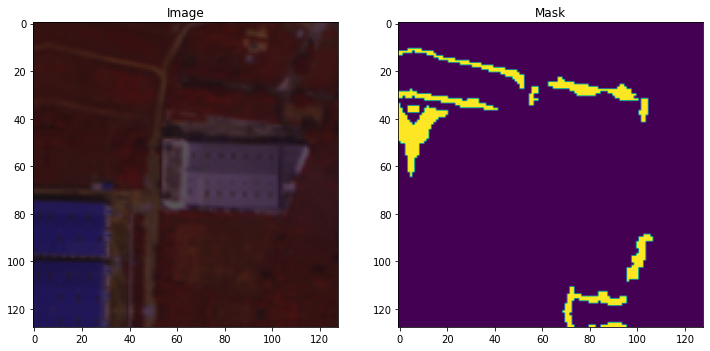

In [13]:
## Train set
tr_num = random.randint(0, np.shape(X_train)[0]-1)
plt.figure(figsize=(12, 8))
plt.subplot(121)
plt.imshow(X_train[tr_num])
plt.title('Image')
plt.subplot(122)
plt.imshow(y_train[tr_num])
plt.title('Mask')
plt.show()

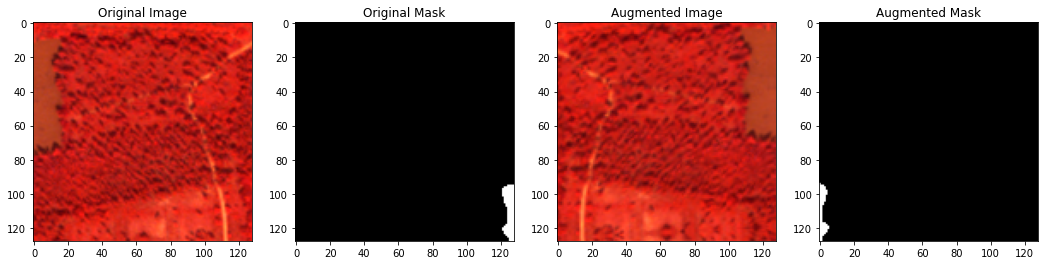

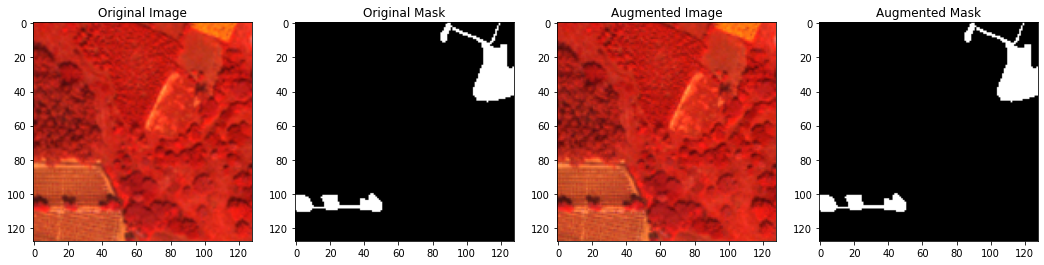

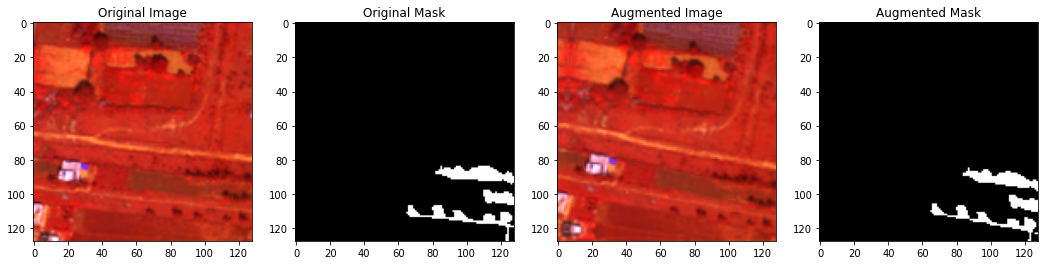

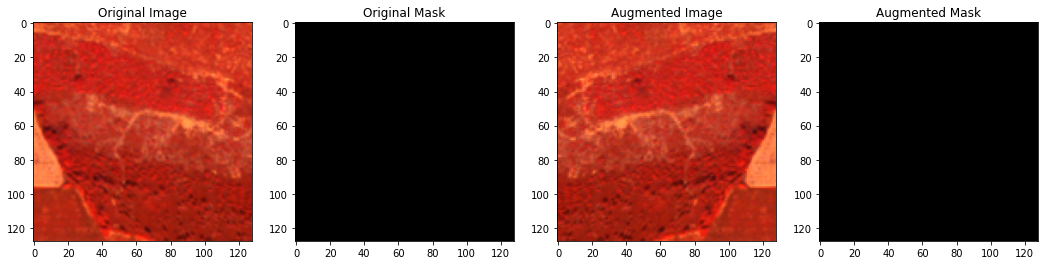

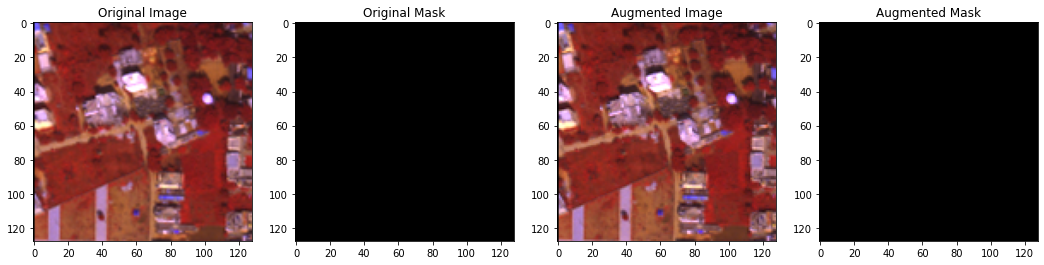

In [14]:
# Function to visualize augmented images and masks
def visualize_augmentation(image_dir, mask_dir, augmentations, num_samples=5, bands=[6, 4, 1]):
    image_files = sorted(os.listdir(image_dir))
    mask_files = sorted(os.listdir(mask_dir))
    
    for i in range(num_samples):
        idx = random.randint(0, len(image_files) - 1)
        
        img_path = os.path.join(image_dir, image_files[idx])
        mask_path = os.path.join(mask_dir, mask_files[idx])
        
        with rasterio.open(img_path) as src:
            img = np.stack([src.read(band) for band in bands], axis=-1).astype(np.float32)

        img = np.clip(img, 0, np.percentile(img, 99))  # Clip out extreme values
        
        # Normalize to [0, 1] before augmentation
        img = (img - img.min()) / (img.max() - img.min())

        with rasterio.open(mask_path) as src:
            mask = src.read(1)
            mask = (mask > 0).astype(np.float32)
        
        # Apply augmentation
        augmented = augmentations(image=img, mask=mask)
        aug_img = augmented['image']
        aug_mask = augmented['mask']

        # Convert images for visualization
        img_display = (img * 255).astype('uint8')  # Correctly scale for display
        aug_img_display = (aug_img * 255).astype('uint8')  # Scale augmented image correctly
        
        # Plot images
        plt.figure(figsize=(18, 6))
        plt.subplot(141)
        plt.imshow(img_display, interpolation='bilinear')
        plt.grid(False)
        plt.title('Original Image')

        plt.subplot(142)
        plt.imshow(mask, cmap='gray')
        plt.grid(False)
        plt.title('Original Mask')

        plt.subplot(143)
        plt.imshow(aug_img_display)
        plt.grid(False)
        plt.title('Augmented Image')

        plt.subplot(144)
        plt.imshow(aug_mask, cmap='gray')
        plt.grid(False)
        plt.title('Augmented Mask')

        plt.show()

# Call the function to visualize augmented data
augmentations_pipeline = get_training_augmentation()
visualize_augmentation(train_image_dir, train_mask_dir, augmentations_pipeline)

In [15]:
# Define backbone and preprocessing function
BACKBONE = 'resnet34'
preprocess_input = sm.get_preprocessing(BACKBONE)

In [16]:
# Preprocess images
X_train = preprocess_input(X_train)
X_val = preprocess_input(X_val)

In [17]:
# Define the model
model = sm.Unet(BACKBONE, encoder_weights='imagenet', classes=n_classes, activation=activation)

# Compile the model
weights = tf.constant([0.052, 0.948])  # Weights for two classes (e.g., background, object)
#weights = tf.constant([0.1, 0.9])  # Weights for two classes (e.g., background, object)
# Create a custom loss that combines Dice and Focal Loss
weighted_dice = weighted_dice_loss(weights)
focal_loss = sm.losses.BinaryFocalLoss()

total_loss = lambda y_true, y_pred: weighted_dice(y_true, y_pred) + focal_loss(y_true, y_pred)

model.compile(optimizer=optim, loss=total_loss, metrics=metrics)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',    # Monitor validation loss
    patience=10,           # Number of epochs with no improvement after which training will stop
    restore_best_weights=True  # Restore model weights from the epoch with the best validation loss
)

# Print model summary
print(model.summary())

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 data (InputLayer)              [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 bn_data (BatchNormalization)   (None, None, None,   9           ['data[0][0]']                   
                                3)                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, None, None,   0          ['bn_data[0][0]']                
                                3)                                                          

In [18]:
## Load the final or best model
import tensorflow as tf

# Load the model
model_path = "/home/pc4dl/satya/Model_development/UNET_resnet34_641.h5"
model = tf.keras.models.load_model(model_path, compile=False)
#model = tf.keras.models.load_model("UNET_resnet34_best.h5", compile=False)

# Define metrics
metrics = [
    'binary_accuracy',  
    sm.metrics.IOUScore(threshold=0.5),  
    sm.metrics.FScore(threshold=0.5)
]

# Recompile the model with the correct metrics
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4), 
              loss=total_loss, 
              metrics=metrics)

print("Model loaded and recompiled successfully!")

Model loaded and recompiled successfully!


In [19]:
# Load test data (Rural Zone)
test_image_dir = os.path.join(base_dir, 'TestingR', 'Image')
test_mask_dir = os.path.join(base_dir, 'TestingR', 'labels')

In [20]:
# Load test images and masks (without augmentation)
print("Loading test data...")
X_test, y_test = load_images_and_masks(test_image_dir, test_mask_dir)

Loading test data...


In [21]:
# Preprocess test images
preprocess_input = sm.get_preprocessing('resnet34')
X_test = preprocess_input(X_test)
# Predict on test data
y_pred = model.predict(X_test)

# Apply a threshold to convert probabilities to binary masks
y_pred_thresholded = (y_pred > 0.5).astype('float32')

2026-08-14 15:46:28.890768: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8100


5/5 [==============================] - 3s 116ms/step


In [22]:
from sklearn.metrics import precision_score, recall_score, average_precision_score
import numpy as np

# Evaluate model on test data (Loss, Binary Accuracy, IOU, F1 Score)
loss, binary_accuracy, iou_score, f1_score = model.evaluate(X_test, y_test, verbose=1)

# Make predictions on test data
y_test_pred = model.predict(X_test, batch_size=batch_size, verbose=1)

# Convert probabilities to binary masks (threshold = 0.5)
y_test_pred_binary = (y_test_pred > 0.7).astype(np.uint8)

# Flatten arrays for metric calculation
y_test_flat = y_test.flatten()
y_test_pred_flat = y_test_pred_binary.flatten()

# Calculate Precision, Recall, and PR-AUC
test_precision = precision_score(y_test_flat, y_test_pred_flat)
test_recall = recall_score(y_test_flat, y_test_pred_flat)
test_pr_auc = average_precision_score(y_test_flat, y_test_pred_flat)

# Print all test metrics
print("\n=== Test Evaluation Metrics ===")
print("Test Loss:", loss)
print("Test Binary Accuracy:", binary_accuracy)
print("Test IOU Score:", iou_score)
print("Test F1 Score:", f1_score)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test PR-AUC:", test_pr_auc)

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089
18/18 [==============================] - 1s 12ms/step

=== Test Evaluation Metrics ===
Test Loss: 0.5832365155220032
Test Binary Accuracy: 0.939917266368866
Test IOU Score: 0.411185085773468
Test F1 Score: 0.5822979807853699
Test Precision: 0.5996088204675226
Test Recall: 0.5693241316511508
Test PR-AUC: 0.3718431489456039


In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def compute_seg_gradcam(model, image, class_index, last_conv_layer_name):
    image_tensor = tf.convert_to_tensor(image[np.newaxis, ...], dtype=tf.float32)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_tensor)
        # For binary segmentation, model output is (1, H, W, 1)
        target_class = predictions[..., 0] if class_index == 1 else 1 - predictions[..., 0]
        class_score = tf.reduce_mean(target_class)

    grads = tape.gradient(class_score, conv_outputs)[0]
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = tf.nn.relu(heatmap)

    heatmap = tf.image.resize(heatmap[..., tf.newaxis], image.shape[:2])
    heatmap = heatmap.numpy().squeeze()

    if np.max(heatmap) != 0:
        heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap))

    return heatmap

def show_multiple_gradcams(image, heatmaps, layer_names):
    fig, axs = plt.subplots(2, len(layer_names)//2, figsize=(20, 6))
    img = np.uint8(255 * (image - image.min()) / (image.max() - image.min()))

    for i, heatmap in enumerate(heatmaps):
        row = i // (len(layer_names)//2)
        col = i % (len(layer_names)//2)
        overlay = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
        blend = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

        axs[row][col].imshow(blend)
        axs[row][col].axis('off')
        axs[row][col].set_title(layer_names[i])

    plt.tight_layout()
    plt.show()

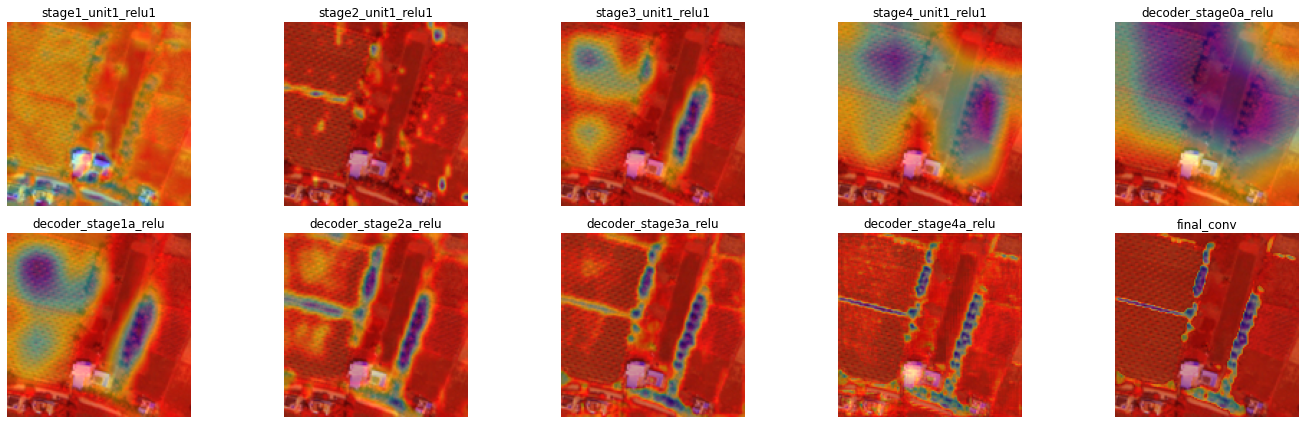

In [24]:
layer_names = [
    "stage1_unit1_relu1",
    "stage2_unit1_relu1",
    "stage3_unit1_relu1",
    "stage4_unit1_relu1",
    "decoder_stage0a_relu",
    "decoder_stage1a_relu",
    "decoder_stage2a_relu",
    "decoder_stage3a_relu",
    "decoder_stage4a_relu",
    "final_conv"
]

image = X_test[0]  # replace with your test image
class_index = 1    # 1 for FMV in binary segmentation

heatmaps = []
for lname in layer_names:
    heatmap = compute_seg_gradcam(model, image, class_index, lname)
    heatmaps.append(heatmap)

show_multiple_gradcams(image, heatmaps, layer_names)

In [25]:
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2

def show_gradcam_with_contours(image, heatmap, alpha=0.5, threshold=0.5, save_path=None):
    # Normalize image
    img = (image - image.min()) / (image.max() - image.min())
    img = np.uint8(255 * img)

    # Resize heatmap if needed
    if heatmap.shape[:2] != img.shape[:2]:
        heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Heatmap color
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)

    # Overlay
    overlay = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)

    # Contours
    thresholded = np.uint8(heatmap > threshold)
    contours, _ = cv2.findContours(thresholded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (0, 255, 0), 2)

    # Create figure explicitly
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    axs[0].imshow(img)
    axs[0].set_title("Original Image")
    axs[0].axis("off")

    im = axs[1].imshow(heatmap, cmap="jet")
    axs[1].set_title("Grad-CAM Heatmap")
    axs[1].axis("off")
    fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)

    axs[2].imshow(overlay)
    axs[2].set_title("Overlay with Contours")
    axs[2].axis("off")
    
    # Reduce spacing
    fig.subplots_adjust(wspace=0.01)

    fig.tight_layout()

    # Save BEFORE show
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=2000, bbox_inches="tight", facecolor="white")
        print(f"Saved to: {save_path}")

    plt.show()
    plt.close(fig)

Saved to: /home/pc4dl/satya/Model_development/GradCAM/gradcam_Xtest102_FMV.png


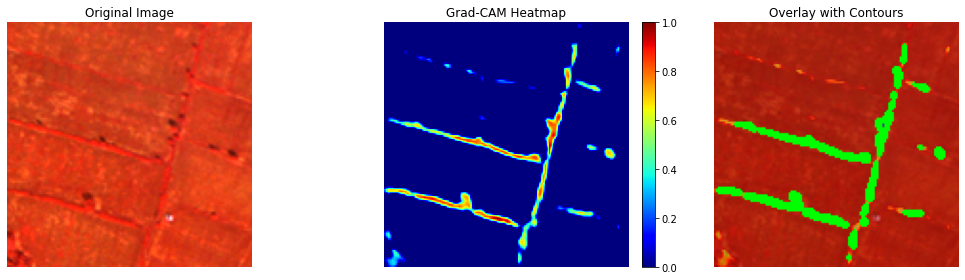

In [26]:
img = X_test[102]
class_index = 1
layer_name = "final_conv"

heatmap = compute_seg_gradcam(model, img, class_index, layer_name)

save_path = "/home/pc4dl/satya/Model_development/GradCAM/gradcam_Xtest102_FMV.png"

show_gradcam_with_contours(
    img,
    heatmap,
    alpha=0.5,
    threshold=0.5,
    save_path=save_path
)

In [27]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def show_gradcam_with_contours_all_layers(model, image, class_index, layer_names, alpha=0.5, threshold=0.5):
    """
    Generate and visualize Grad-CAM overlays with contours for multiple layers.
    """

    image_norm = (image - image.min()) / (image.max() - image.min())
    img_uint8 = np.uint8(255 * image_norm)

    fig, axs = plt.subplots(len(layer_names), 3, figsize=(12, 4 * len(layer_names)))

    # Handle case when only one layer
    if len(layer_names) == 1:
        axs = np.expand_dims(axs, axis=0)

    for i, layer_name in enumerate(layer_names):

        # --- Grad-CAM computation ---
        heatmap = compute_seg_gradcam(model, image, class_index, layer_name)

        # Apply color map
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
        overlay = cv2.addWeighted(img_uint8, 1 - alpha, heatmap_color, alpha, 0)

        # Find contours
        binary_mask = np.uint8(heatmap > threshold)
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay, contours, -1, (0, 255, 0), 2)

        # --- Original Image ---
        axs[i, 0].imshow(img_uint8)
        axs[i, 0].set_title("Original Image")
        axs[i, 0].axis("off")

        # --- Heatmap ---
        im = axs[i, 1].imshow(heatmap, cmap="jet")
        axs[i, 1].set_title(f"Heatmap ({layer_name})")
        axs[i, 1].axis("off")

        # Add colorbar without resizing axis
        divider = make_axes_locatable(axs[i, 1])
        cax = divider.append_axes("right", size="5%", pad=0.05)
        fig.colorbar(im, cax=cax)

        # --- Overlay + Contours ---
        axs[i, 2].imshow(overlay)
        axs[i, 2].set_title("Overlay + Contours")
        axs[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

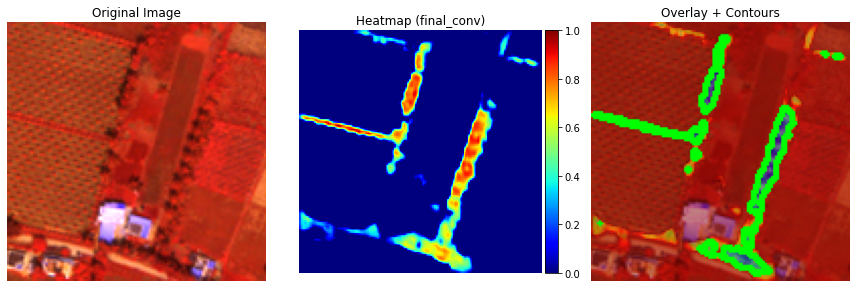

In [28]:
img = X_test[0]
class_index = 1
layer_names = ["final_conv"]

# Save output to file
show_gradcam_with_contours_all_layers(
    model, img, class_index, layer_names,
    #save_path="gradcam_Xtest0_fmv.png"
)